In [17]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, ivreg, modelsummary)

In [8]:
final.hcris.data <- read_csv('../data/output/HCRIS_final.csv')

Rows: 133679 Columns: 51
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (9): provider_number, data_source, street, city, state, zip, county, n...
dbl  (38): beds, tot_charges, net_pat_rev, tot_discounts, tot_operating_exp,...
date  (4): fy_start, fy_end, date_processed, date_created

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 78508 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (34): report, status, year, beds, tot_charges, net_pat_rev, tot_discount...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 57802 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (35): report, status, year, beds, tot_charges, tot_discounts, net_pat_re...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `line

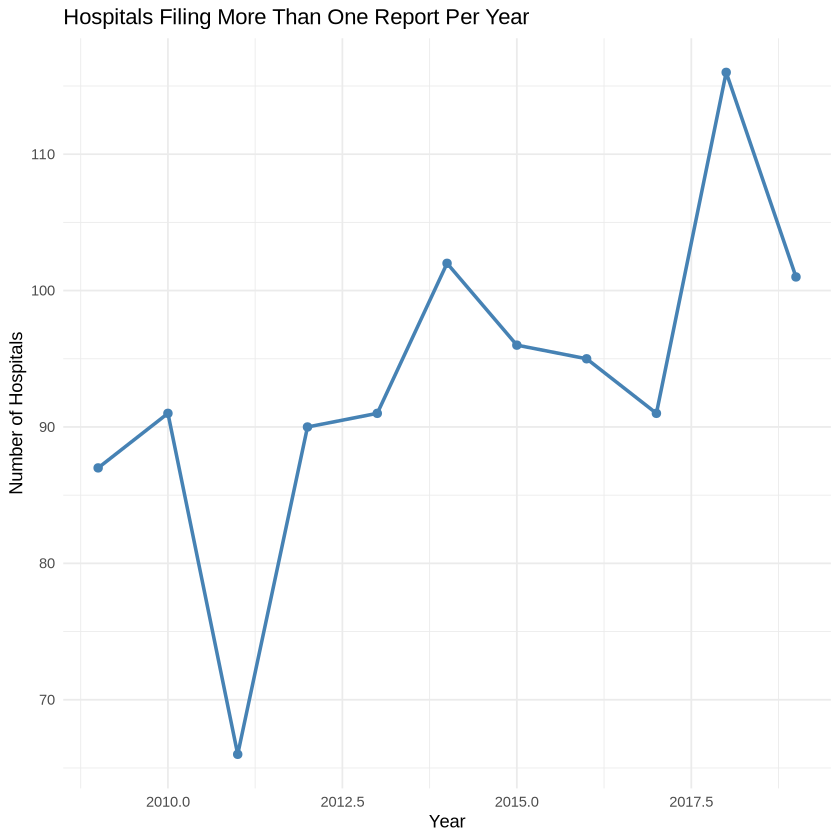

In [5]:
#Q1
final.hcris.v1996 = read_csv('../data/output/HCRIS_Data_v1996.csv')
final.hcris.v2010 = read_csv('../data/output/HCRIS_Data_v2010.csv')

final.hcris.v1996 = final.hcris.v1996 %>%
  mutate(hvbp_payment=NA, hrrp_payment=NA)

final.hcris = bind_rows(final.hcris.v1996, final.hcris.v2010) %>%
  mutate(fy_end=mdy(fy_end), fy_start=mdy(fy_start),
         date_processed=mdy(date_processed), date_created=mdy(date_created),
         tot_discounts=abs(tot_discounts), hrrp_payment=abs(hrrp_payment)) %>%
  mutate(fyear=year(fy_end)) %>%
  arrange(provider_number, fyear) %>%
  select(-year)

q1 <- final.hcris %>%
  filter(fyear >= 2009, fyear <= 2019) %>%
  group_by(provider_number, fyear) %>%
  summarize(n_reports = n(), .groups = "drop") %>%
  filter(n_reports > 1) %>%
  group_by(fyear) %>%
  summarize(n_hospitals = n())

ggplot(q1, aes(x = fyear, y = n_hospitals)) +
  geom_line(color = "steelblue", size = 1) +
  geom_point(color = "steelblue", size = 2) +
  labs(title = "Hospitals Filing More Than One Report Per Year",
       x = "Year", y = "Number of Hospitals") +
  theme_minimal()

In [9]:
#Q2
n_unique <- final.hcris.data %>%
  distinct(provider_number) %>%
  nrow()

cat("Number of unique hospital IDs:", n_unique, "\n")

Number of unique hospital IDs: 9451 


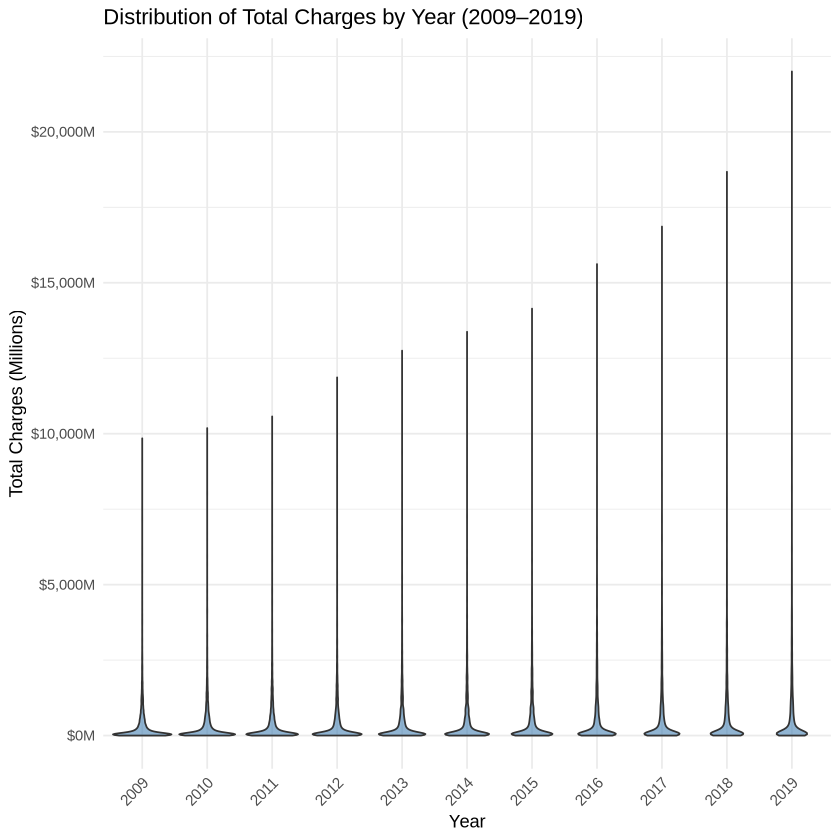

In [10]:
#Q3
q3 <- final.hcris.data %>%
  filter(year >= 2009, year <= 2019) %>%
  filter(!is.na(tot_charges), tot_charges > 0)

ggplot(q3, aes(x = factor(year), y = tot_charges)) +
  geom_violin(fill = "steelblue", alpha = 0.6) +
  scale_y_continuous(labels = scales::dollar_format(scale = 1e-6, suffix = "M")) +
  labs(title = "Distribution of Total Charges by Year (2009–2019)",
       x = "Year", y = "Total Charges (Millions)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

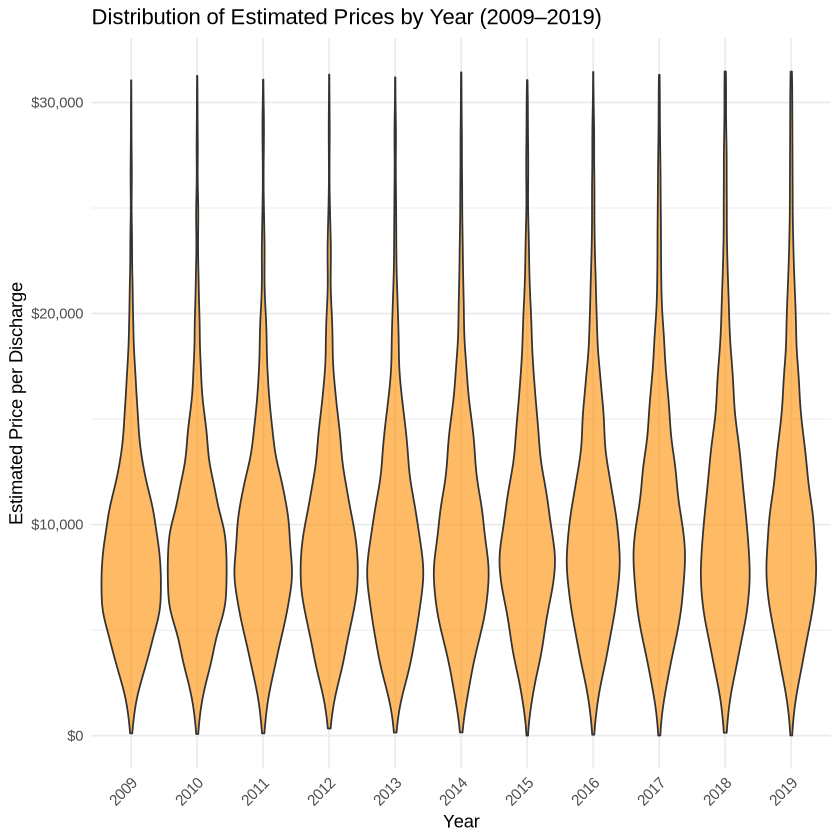

In [11]:
#Q4
q4 <- final.hcris.data %>%
  filter(year >= 2009, year <= 2019) %>%
  mutate(
    discount_factor = 1 - tot_discounts / tot_charges,
    price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
    price_denom = tot_discharges - mcare_discharges,
    price = price_num / price_denom
  ) %>%
  filter(
    !is.na(price),
    !is.infinite(price),
    price > 0,
    price < quantile(price, 0.99, na.rm = TRUE)
  )

ggplot(q4, aes(x = factor(year), y = price)) +
  geom_violin(fill = "darkorange", alpha = 0.6) +
  scale_y_continuous(labels = scales::dollar_format()) +
  labs(title = "Distribution of Estimated Prices by Year (2009–2019)",
       x = "Year", y = "Estimated Price per Discharge") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

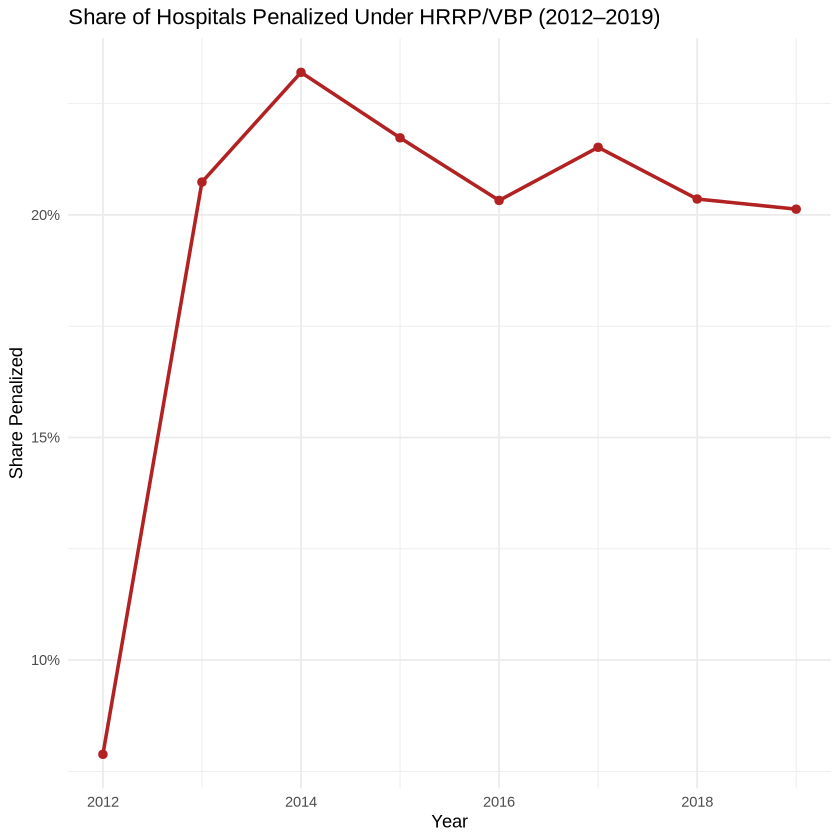

In [12]:
#Q5
q5 <- final.hcris.data %>%
  filter(year >= 2012, year <= 2019) %>%
  mutate(
    penalized = (!is.na(hrrp_payment) & hrrp_payment < 0) |
                (!is.na(hvbp_payment) & hvbp_payment < 0)
  ) %>%
  group_by(year) %>%
  summarize(share_penalized = mean(penalized, na.rm = TRUE))

ggplot(q5, aes(x = year, y = share_penalized)) +
  geom_line(color = "firebrick", size = 1) +
  geom_point(color = "firebrick", size = 2) +
  scale_y_continuous(labels = scales::percent_format()) +
  labs(title = "Share of Hospitals Penalized Under HRRP/VBP (2012–2019)",
       x = "Year", y = "Share Penalized") +
  theme_minimal()

In [15]:
# Price calculation helper
calc_price <- function(df) {
  df %>%
    mutate(
      discount_factor = 1 - tot_discounts / tot_charges,
      price_num = (ip_charges + icu_charges + ancillary_charges) * discount_factor - tot_mcare_payment,
      price_denom = tot_discharges - mcare_discharges,
      price = price_num / price_denom
    )
}

# Prices in 2011 and 2014
price_2011 <- final.hcris.data %>%
  filter(year == 2011) %>%
  calc_price() %>%
  select(provider_number, price_2011 = price)

price_2014 <- final.hcris.data %>%
  filter(year == 2014) %>%
  calc_price() %>%
  select(provider_number, price_2014 = price)

# 2012 net penalty
penalty_2012 <- final.hcris.data %>%
  filter(year == 2012) %>%
  mutate(
    hrrp = replace_na(hrrp_payment, 0),
    hvbp = replace_na(hvbp_payment, 0),
    net_penalty = hrrp + hvbp,
    penalized = as.integer(net_penalty < 0)
  ) %>%
  select(provider_number, net_penalty, penalized)

# Pre-2012 averages (2009-2011)
pre2012 <- final.hcris.data %>%
  filter(year >= 2009, year <= 2011) %>%
  group_by(provider_number) %>%
  summarize(
    avg_mcare_discharges = mean(mcare_discharges, na.rm = TRUE),
    avg_beds = mean(beds, na.rm = TRUE),
    avg_mcaid_discharges = mean(mcaid_discharges, na.rm = TRUE)
  )

# Build analysis dataset
iv_data <- price_2011 %>%
  inner_join(price_2014, by = "provider_number") %>%
  inner_join(penalty_2012, by = "provider_number") %>%
  inner_join(pre2012, by = "provider_number") %>%
  mutate(price_change = price_2014 - price_2011) %>%
  filter(
    !is.na(price_change),
    !is.infinite(price_change),
    price_2011 > 0,
    price_2014 > 0,
    price_change > quantile(price_change, 0.01, na.rm = TRUE),
    price_change < quantile(price_change, 0.99, na.rm = TRUE)
  )

cat("Observations in IV dataset:", nrow(iv_data), "\n")

Observations in IV dataset: 2449 


In [19]:
#Q6
ols1 <- lm(price_change ~ net_penalty, data = iv_data)
ols2 <- lm(price_change ~ net_penalty + avg_beds, data = iv_data)
ols3 <- lm(price_change ~ net_penalty + avg_beds + avg_mcaid_discharges, data = iv_data)

modelsummary(
  list("Baseline" = ols1, "+ Beds" = ols2, "+ Beds + Medicaid" = ols3),
  title = "OLS Estimates: Effect of Net Penalty on Price Change",
  stars = TRUE,
  gof_omit = "AIC|BIC|Log",
  output = "markdown"
)



Table: OLS Estimates: Effect of Net Penalty on Price Change

|                      |  Baseline  |   + Beds   | + Beds + Medicaid | 
|:---------------------|-----------:|-----------:|------------------:|
| (Intercept)          | 247.380*** | 229.061*** |      106.284+     | 
|                      |  (47.055)  |  (47.565)  |      (58.872)     | 
| net_penalty          |    0.002   |    0.002   |       0.002       | 
|                      |   (0.001)  |   (0.001)  |      (0.001)      | 
| avg_beds             |            |   0.074*   |       0.067*      | 
|                      |            |   (0.030)  |      (0.030)      | 
| avg_mcaid_discharges |            |            |      0.077***     | 
|                      |            |            |      (0.022)      | 
| Num.Obs.             |    2449    |    2449    |        2440       | 
| R2                   |    0.001   |    0.004   |       0.009       | 
| R2 Adj.              |    0.001   |    0.003   |       0.007       | 
| 

`geom_smooth()` using formula = 'y ~ x'


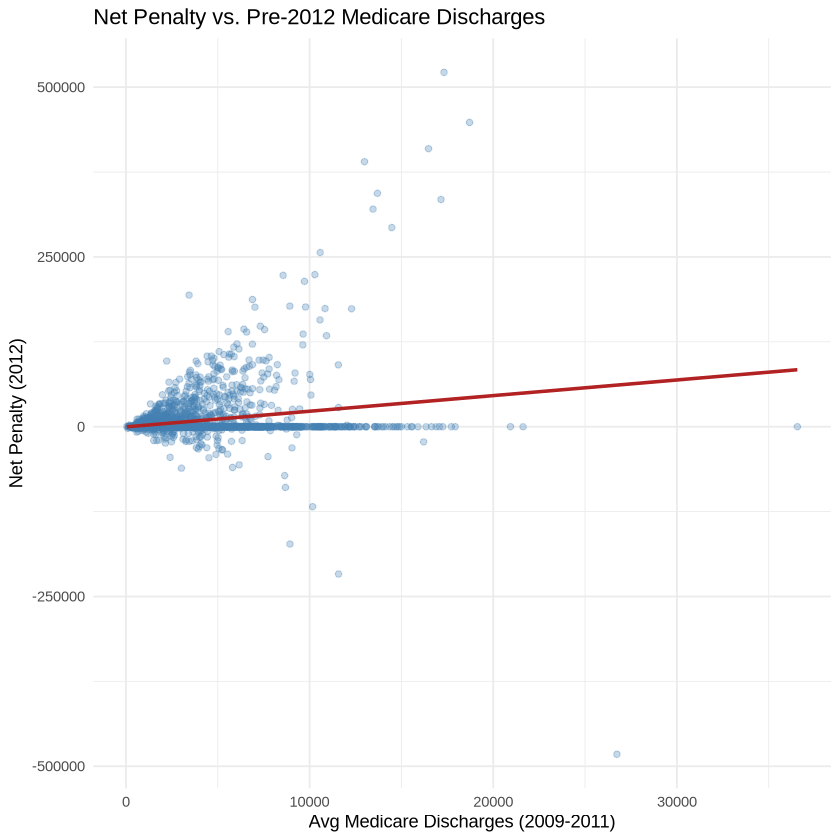

In [20]:
#Q7
ggplot(iv_data, aes(x = avg_mcare_discharges, y = net_penalty)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_smooth(method = "lm", color = "firebrick", se = FALSE) +
  labs(title = "Net Penalty vs. Pre-2012 Medicare Discharges",
       x = "Avg Medicare Discharges (2009-2011)",
       y = "Net Penalty (2012)") +
  theme_minimal()

In [23]:
#Q8
fs1 <- lm(net_penalty ~ avg_mcare_discharges, data = iv_data)
fs2 <- lm(net_penalty ~ avg_mcare_discharges + avg_beds, data = iv_data)
fs3 <- lm(net_penalty ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges, data = iv_data)

rf1 <- lm(price_change ~ avg_mcare_discharges, data = iv_data)
rf2 <- lm(price_change ~ avg_mcare_discharges + avg_beds, data = iv_data)
rf3 <- lm(price_change ~ avg_mcare_discharges + avg_beds + avg_mcaid_discharges, data = iv_data)

modelsummary(
  list("FS Baseline" = fs1, "FS + Beds" = fs2, "FS + Beds + Medicaid" = fs3,
       "RF Baseline" = rf1, "RF + Beds" = rf2, "RF + Beds + Medicaid" = rf3),
  title = "First Stage and Reduced Form Results",
  stars = TRUE,
  gof_omit = "AIC|BIC|Log",
  output = "markdown"
)



Table: First Stage and Reduced Form Results

|                      | FS Baseline |  FS + Beds | FS + Beds + Medicaid | RF Baseline | RF + Beds | RF + Beds + Medicaid | 
|:---------------------|------------:|-----------:|---------------------:|------------:|----------:|---------------------:|
| (Intercept)          |   -242.017  |  -232.107  |        295.239       |   168.136*  |  163.442* |       126.855+       | 
|                      |  (1046.415) | (1047.025) |      (1061.451)      |   (70.135)  |  (70.097) |       (71.048)       | 
| avg_mcare_discharges |   2.303***  |  2.310***  |       2.717***       |    0.027+   |   0.023   |        -0.003        | 
|                      |   (0.220)   |   (0.221)  |        (0.254)       |   (0.015)   |  (0.015)  |        (0.017)       | 
| avg_beds             |             |   -0.148   |        -0.110        |             |   0.070*  |        0.068*        | 
|                      |             |   (0.443)  |        (0.443)       |     

In [25]:
#Q9
iv1 <- ivreg(price_change ~ net_penalty | avg_mcare_discharges, data = iv_data)
iv2 <- ivreg(price_change ~ net_penalty + avg_beds | avg_mcare_discharges + avg_beds, data = iv_data)
iv3 <- ivreg(price_change ~ net_penalty + avg_beds + avg_mcaid_discharges |
               avg_mcare_discharges + avg_beds + avg_mcaid_discharges, data = iv_data)

modelsummary(
  list("IV Baseline" = iv1, "IV + Beds" = iv2, "IV + Beds + Medicaid" = iv3),
  title = "IV Estimates: Effect of Net Penalty on Price Change",
  stars = TRUE,
  gof_omit = "AIC|BIC|Log",
  output = "markdown"
)



Table: IV Estimates: Effect of Net Penalty on Price Change

|                      | IV Baseline | IV + Beds | IV + Beds + Medicaid | 
|:---------------------|------------:|----------:|---------------------:|
| (Intercept)          |   170.955*  |  165.775* |       127.194+       | 
|                      |   (69.697)  |  (69.493) |       (72.172)       | 
| net_penalty          |    0.012+   |   0.010   |        -0.001        | 
|                      |   (0.006)   |  (0.006)  |        (0.006)       | 
| avg_beds             |             |   0.072*  |        0.067*        | 
|                      |             |  (0.030)  |        (0.030)       | 
| avg_mcaid_discharges |             |           |       0.079***       | 
|                      |             |           |        (0.023)       | 
| Num.Obs.             |     2449    |    2449   |         2440         | 
| R2                   |    -0.020   |   -0.011  |         0.006        | 
| R2 Adj.              |    -0.020   | 

In [ ]:
#Q10
#The IV estimator identifies a **Local Average Treatment Effect (LATE)** which is the effect of penalties on price changes 
#only for hospitals whose penalty status was driven by their pre-2012 Medicare discharge volume (the "compliers"). 
#In this setting, compliers tend to be hospitals with higher Medicare exposure, which may respond differently to penalties than the average 
#hospital, meaning the LATE could differ from the overall ATE. Our IV estimates (0.012 baseline, becoming insignificant with controls) 
#suggest the local effect among these Medicare-heavy hospitals is modest at best.